In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("listings.csv")

In [3]:
a = df.head(5)
print(a)


        id                           listing_url       scrape_id last_scraped  \
0  2992450  https://www.airbnb.com/rooms/2992450  20251107023918   2025-11-07   
1  3820211  https://www.airbnb.com/rooms/3820211  20251107023918   2025-11-07   
2  5651579  https://www.airbnb.com/rooms/5651579  20251107023918   2025-11-07   
3  6623339  https://www.airbnb.com/rooms/6623339  20251107023918   2025-11-07   
4  9005989  https://www.airbnb.com/rooms/9005989  20251107023918   2025-11-07   

        source                                              name  \
0  city scrape                        Luxury 2 bedroom apartment   
1  city scrape         Restored Precinct in Center Sq. w/Parking   
2  city scrape        Large studio apt  by Capital Center & ESP@   
3  city scrape  Center Sq. Loft in Converted Precinct w/ Parking   
4  city scrape    Studio in The heart of Center SQ, in Albany NY   

                                         description  \
0  The apartment is located in a quiet neighborh

In [4]:
print(df.shape)

(478, 79)


In [5]:

print("Shape:", df.shape)
print(df.dtypes)

Shape: (478, 79)
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object


In [6]:
print("\n--- MISSING VALUES ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))



--- MISSING VALUES ---
                              Missing Count  Missing %
neighbourhood_group_cleansed            478     100.00
license                                 478     100.00
calendar_updated                        478     100.00
neighbourhood                           291      60.88
neighborhood_overview                   291      60.88
host_about                              230      48.12
host_location                           125      26.15
reviews_per_month                        68      14.23
review_scores_value                      68      14.23
first_review                             68      14.23
review_scores_accuracy                   68      14.23
review_scores_checkin                    68      14.23
review_scores_cleanliness                68      14.23
review_scores_rating                     68      14.23
last_review                              68      14.23
review_scores_location                   68      14.23
review_scores_communication              

In [7]:
print(df.describe())

                 id     scrape_id       host_id  host_listings_count  \
count  4.780000e+02  4.780000e+02  4.780000e+02           478.000000   
mean   8.557695e+17  2.025111e+13  2.567199e+08            27.384937   
std    5.530102e+17  0.000000e+00  2.001281e+08           139.990125   
min    2.992450e+06  2.025111e+13  6.576000e+04             1.000000   
25%    5.436924e+07  2.025111e+13  4.871052e+07             2.000000   
50%    9.915277e+17  2.025111e+13  2.329679e+08             5.000000   
75%    1.328363e+18  2.025111e+13  4.402725e+08            17.000000   
max    1.545066e+18  2.025111e+13  7.105525e+08          1239.000000   

       host_total_listings_count  neighbourhood_group_cleansed    latitude  \
count                 478.000000                           0.0  478.000000   
mean                   48.853556                           NaN   42.659161   
std                   303.176218                           NaN    0.010570   
min                     1.000000       

In [8]:
df.drop(columns=['neighbourhood_group_cleansed', 'license', 'calendar_updated'], inplace=True) # this are empty so i am removing this 

In [9]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float) #we are making price as float 

In [10]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%','').astype(float)
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%','').astype(float) #same concept with this also 

In [11]:
df.dropna(subset=['price'], inplace=True) #without price we cant anlaysis so we are removing the epty row 

In [12]:
review_cols = ['review_scores_rating','review_scores_accuracy','review_scores_cleanliness',
               'review_scores_checkin','review_scores_communication',
               'review_scores_location','review_scores_value']
df[review_cols] = df[review_cols].fillna(df[review_cols].median())  #we are filling with median imputation only the empty row 

In [13]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0) #we can say there were no review for that month that why it is not calculated 

In [14]:
for col in ['beds', 'bedrooms', 'bathrooms']:
    df[col] = df[col].fillna(df[col].median())

In [15]:
df['host_since'] = pd.to_datetime(df['host_since'])
df['first_review'] = pd.to_datetime(df['first_review'])
df['last_review'] = pd.to_datetime(df['last_review'])

In [16]:
#checking after cleaning

print(df.isnull().sum())
print(df.shape)

id                                              0
listing_url                                     0
scrape_id                                       0
last_scraped                                    0
source                                          0
                                               ..
calculated_host_listings_count                  0
calculated_host_listings_count_entire_homes     0
calculated_host_listings_count_private_rooms    0
calculated_host_listings_count_shared_rooms     0
reviews_per_month                               0
Length: 76, dtype: int64
(437, 76)


In [17]:
from ydata_profiling import ProfileReport

# minimal=True makes the report much smaller
profile = ProfileReport(
    df,
    title="Albany Airbnb EDA",
    minimal=True,                    # ← this is the key
    explorative=False,
    correlations=None,
    missing_diagrams=None,
    duplicates=None,
    samples=None
)

profile.to_file("airbnb_report_small.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 76/76 [00:01<00:00, 49.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_cols)
print("Total:", len(numeric_cols))

Numeric columns: ['id', 'scrape_id', 'host_id', 'host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_

Q1: $68.0 | Q3: $122.0 | IQR: $54.0
Lower bound: $-13.00 | Upper bound: $203.00


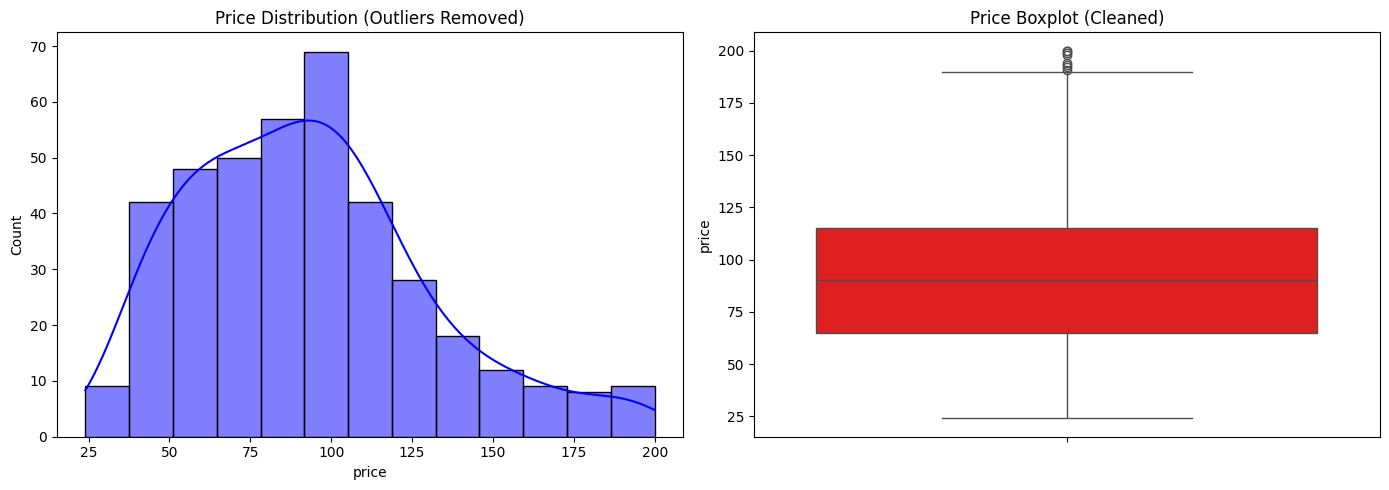


New Mean:     $92.86
New Median:   $90.00
New Skewness: 0.69


In [19]:
# Remove price outliers using IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: ${Q1} | Q3: ${Q3} | IQR: ${IQR}")
print(f"Lower bound: ${lower:.2f} | Upper bound: ${upper:.2f}")

df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Price Distribution (Outliers Removed)')
sns.boxplot(df_clean['price'], ax=axes[1], color='red')
axes[1].set_title('Price Boxplot (Cleaned)')
plt.tight_layout()
plt.show()
print(f"\nNew Mean:     ${df_clean['price'].mean():.2f}")
print(f"New Median:   ${df_clean['price'].median():.2f}")
print(f"New Skewness: {df_clean['price'].skew():.2f}")

In [20]:
df = df_clean.copy()
print("✅ df updated:", df.shape)

✅ df updated: (401, 76)


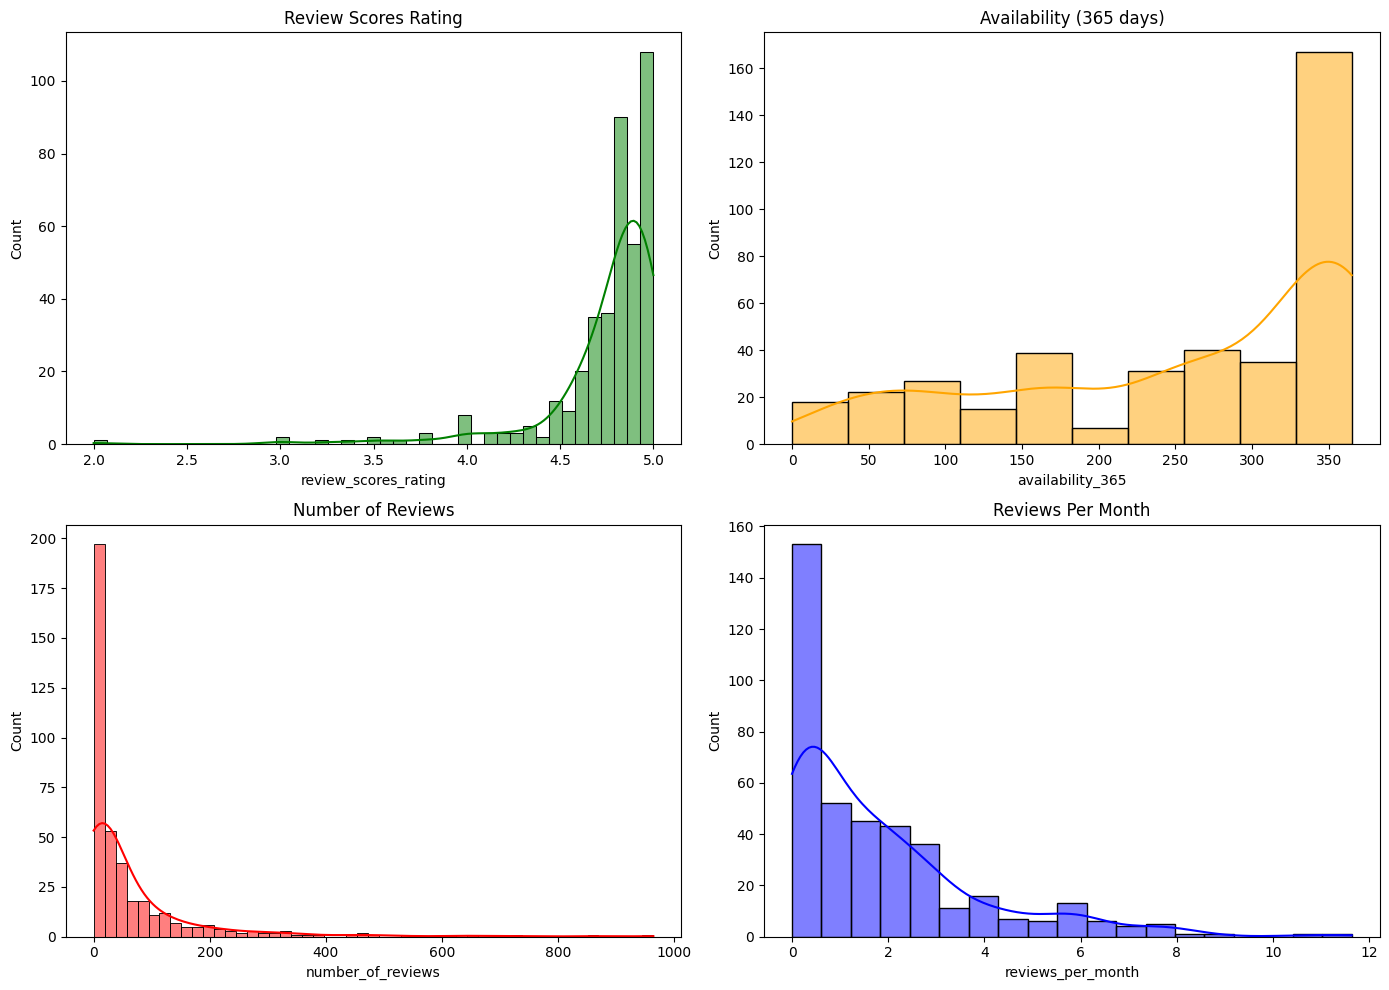

review_scores_rating: skewness = -3.50
availability_365: skewness = -0.75
number_of_reviews: skewness = 3.79
reviews_per_month: skewness = 1.66


In [21]:
# Analyse review score rating + availability
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Review score
sns.histplot(df['review_scores_rating'], kde=True, ax=axes[0,0], color='green')
axes[0,0].set_title('Review Scores Rating')

# Availability 365
sns.histplot(df['availability_365'], kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Availability (365 days)')

# Number of reviews
sns.histplot(df['number_of_reviews'], kde=True, ax=axes[1,0], color='red')
axes[1,0].set_title('Number of Reviews')

# Reviews per month
sns.histplot(df['reviews_per_month'], kde=True, ax=axes[1,1], color='blue')
axes[1,1].set_title('Reviews Per Month')

plt.tight_layout()
plt.show()

# Skewness summary
cols = ['review_scores_rating','availability_365','number_of_reviews','reviews_per_month']
for col in cols:
    print(f"{col}: skewness = {df[col].skew():.2f}")

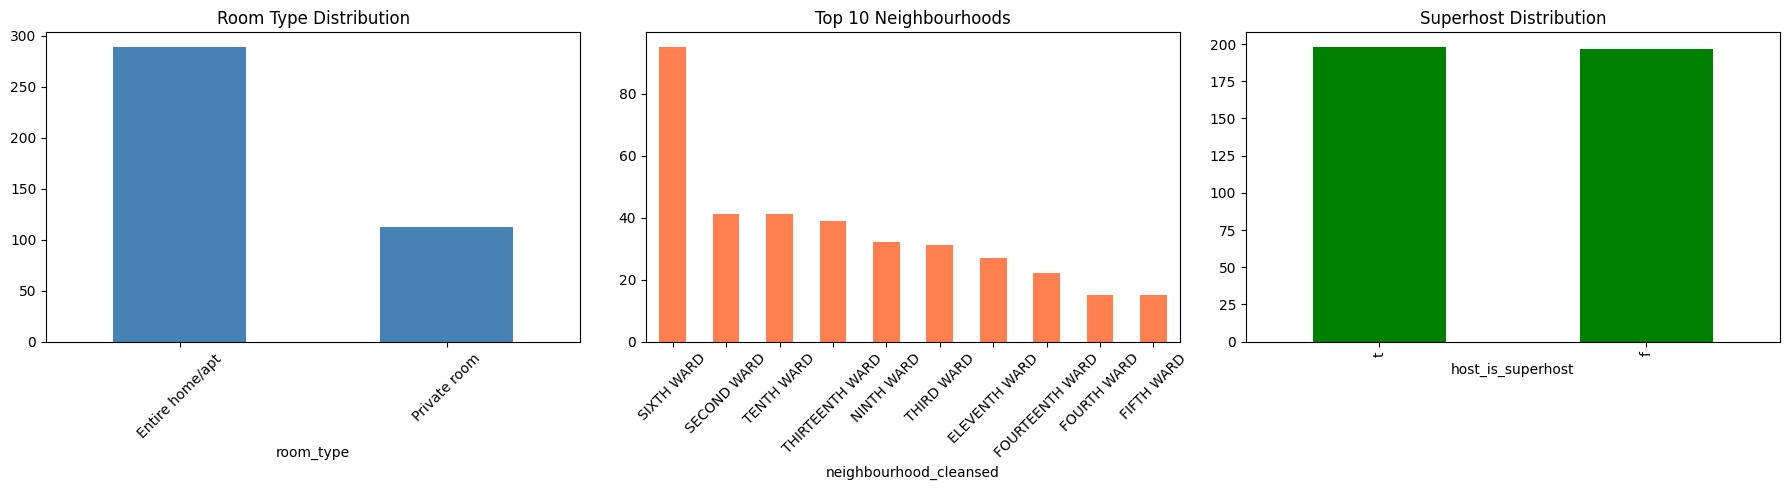

listing_url: 401 unique values
last_scraped: 1 unique values
source: 1 unique values
name: 398 unique values
description: 343 unique values
neighborhood_overview: 116 unique values
picture_url: 392 unique values
host_url: 169 unique values
host_name: 149 unique values
host_location: 29 unique values
host_about: 83 unique values
host_response_time: 4 unique values
host_is_superhost: 2 unique values
host_thumbnail_url: 158 unique values
host_picture_url: 158 unique values
host_neighbourhood: 33 unique values
host_verifications: 3 unique values
host_has_profile_pic: 2 unique values
host_identity_verified: 2 unique values
neighbourhood: 1 unique values
neighbourhood_cleansed: 15 unique values
property_type: 18 unique values
room_type: 2 unique values
bathrooms_text: 13 unique values
amenities: 389 unique values
has_availability: 1 unique values
calendar_last_scraped: 1 unique values
instant_bookable: 2 unique values


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Room type
df['room_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Room Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Neighbourhood
df['neighbourhood_cleansed'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Neighbourhoods')
axes[1].tick_params(axis='x', rotation=45)

# Host is superhost
df['host_is_superhost'].value_counts().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Superhost Distribution')

plt.tight_layout()
plt.show()

# Cardinality check
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

In [23]:


# Drop useless high cardinality and single value columns
drop_cols = [
    'listing_url', 'picture_url', 'host_url',
    'host_thumbnail_url', 'host_picture_url',
    'last_scraped', 'source', 'calendar_last_scraped',
    'scrape_id', 'neighbourhood'
]
df.drop(columns=drop_cols, inplace=True)

# Convert t/f columns to 1/0
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

print("✅ Shape after cleanup:", df.shape)
print("\nBool columns converted:")
print(df[bool_cols].head())

✅ Shape after cleanup: (401, 66)

Bool columns converted:
   host_is_superhost  host_has_profile_pic  host_identity_verified  \
0                0.0                     1                       1   
1                1.0                     1                       1   
2                1.0                     1                       1   
3                1.0                     1                       1   
4                0.0                     1                       1   

   has_availability  instant_bookable  
0               1.0                 0  
1               1.0                 0  
2               1.0                 0  
3               1.0                 0  
4               1.0                 0  


In [24]:
from scipy import stats

# Select numeric columns (excluding IDs and useless ones)
skip_cols = ['id', 'scrape_id', 'host_id', 'latitude', 'longitude']
num_cols = [col for col in df.select_dtypes(include='number').columns 
            if col not in skip_cols]

# Drop columns with near-zero variance (std < 0.01) to avoid the warning
num_cols = [col for col in num_cols if df[col].std() > 0.01]

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[num_cols].dropna()))

# Find outliers (|Z| > 3)
outlier_mask = (z_scores > 3)
outlier_counts = outlier_mask.sum(axis=0)

# Show result
outlier_df = pd.DataFrame({
    'Column': num_cols,
    'Outlier Count': outlier_counts,
    'Outlier %': (outlier_counts / len(df) * 100).round(2)
})

outlier_df = outlier_df[outlier_df['Outlier Count'] > 0].sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

                     Column  Outlier Count  Outlier %
     host_identity_verified             28       6.98
       host_acceptance_rate             14       3.49
       host_has_profile_pic             12       2.99
                  bathrooms             11       2.74
       number_of_reviews_ly             10       2.49
          number_of_reviews              9       2.24
      number_of_reviews_ltm              8       2.00
     review_scores_accuracy              8       2.00
        review_scores_value              8       2.00
      review_scores_checkin              7       1.75
                       beds              7       1.75
       review_scores_rating              7       1.75
     number_of_reviews_l30d              7       1.75
  review_scores_cleanliness              6       1.50
         host_response_rate              5       1.25
                   bedrooms              4       1.00
review_scores_communication              4       1.00
     review_scores_location 

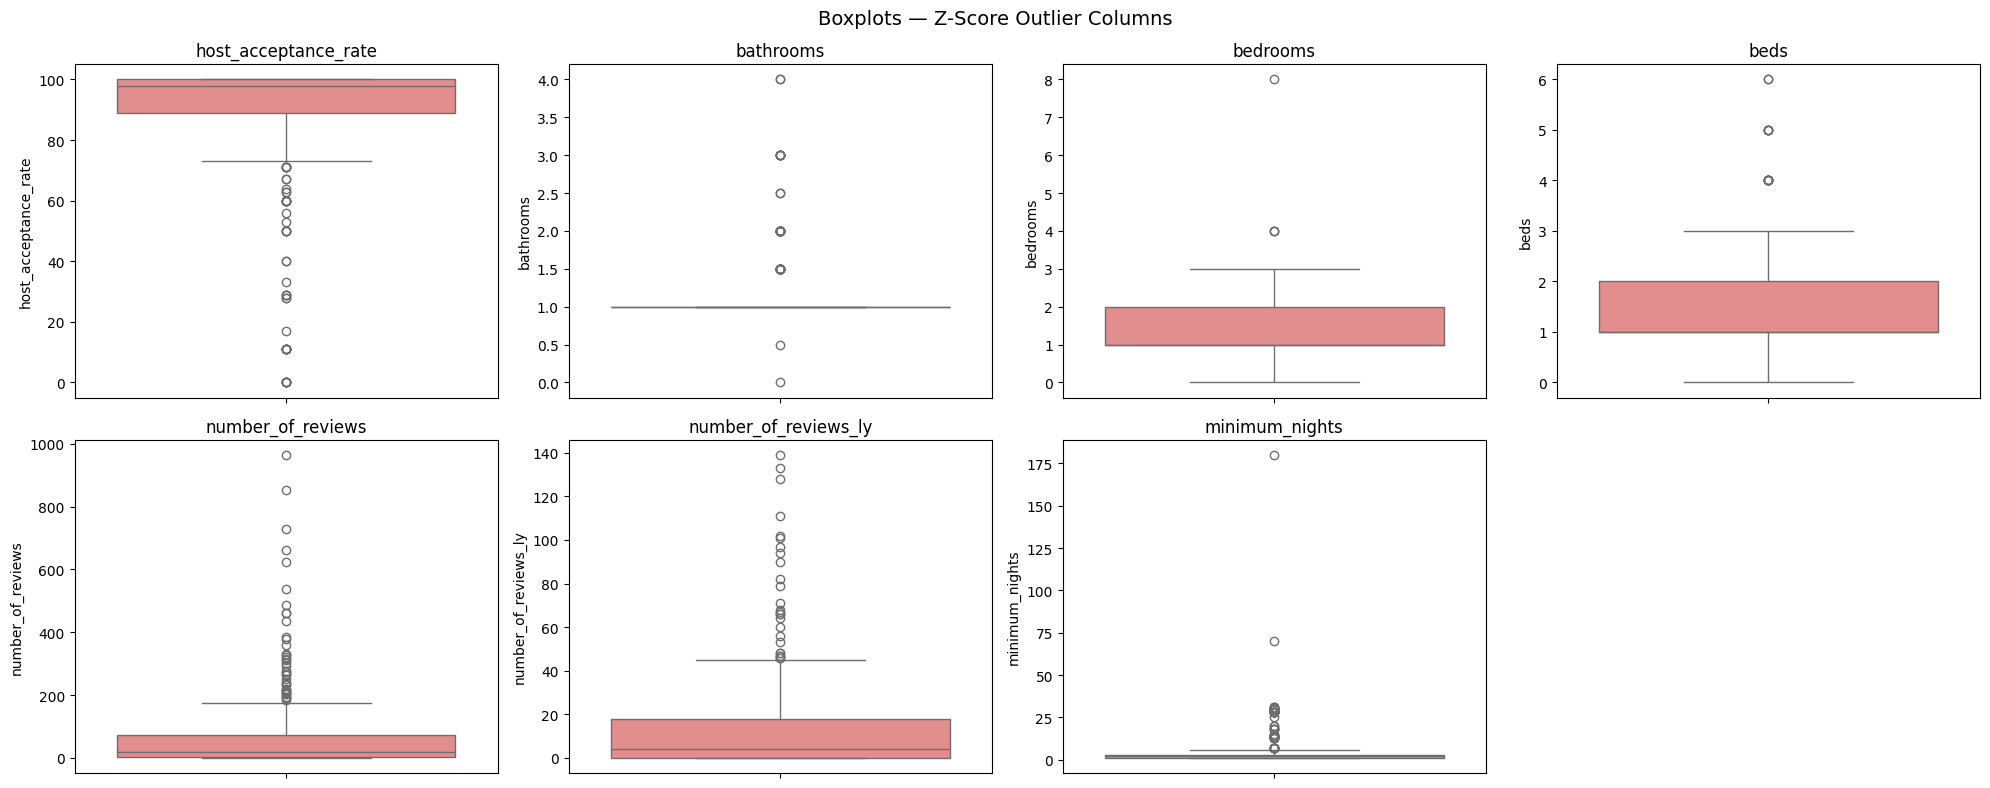

In [25]:
# Visualize the meaningful outlier columns (skip binary ones)
check_cols = ['host_acceptance_rate', 'bathrooms', 'bedrooms', 'beds',
              'number_of_reviews', 'number_of_reviews_ly', 'minimum_nights']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}')

axes[-1].set_visible(False)  # hide last empty subplot
plt.suptitle('Boxplots — Z-Score Outlier Columns', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Cap minimum_nights at 90 days (3 months max)
df['minimum_nights'] = df['minimum_nights'].clip(upper=90)

print(f" minimum_nights capped at 90")
print(f"New max: {df['minimum_nights'].max()} nights")
print(f"Shape: {df.shape}")

 minimum_nights capped at 90
New max: 90 nights
Shape: (401, 66)


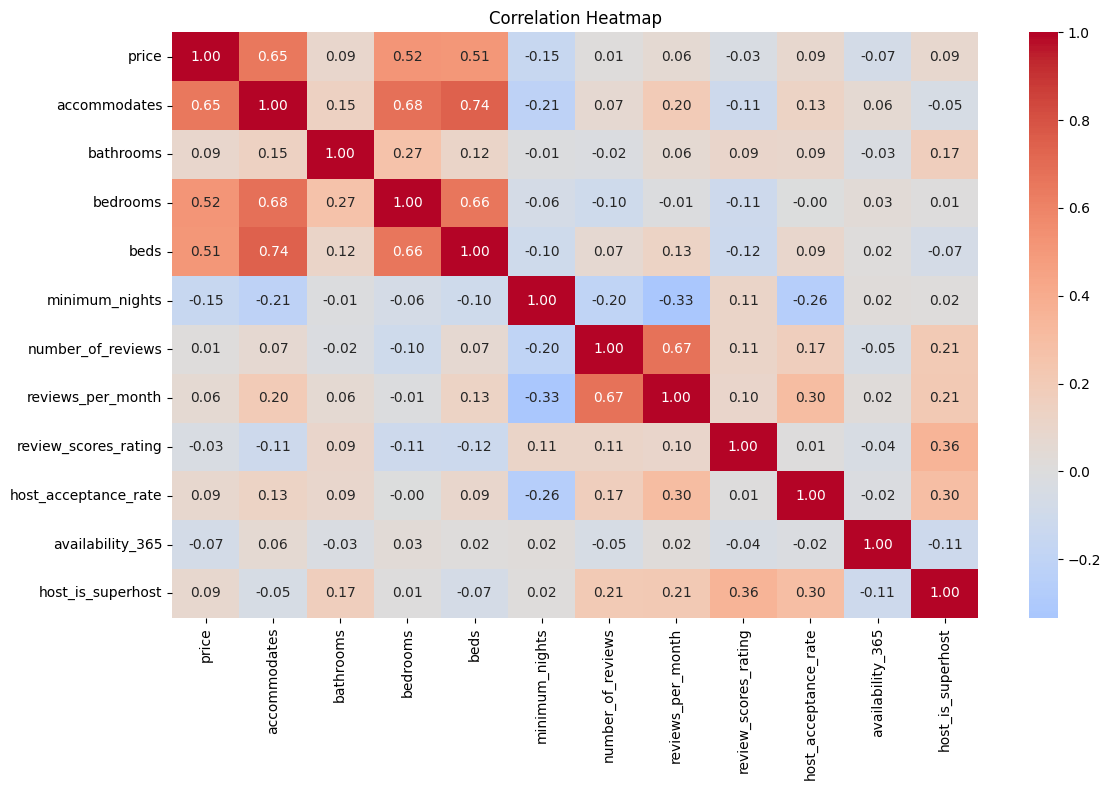

In [27]:
# Select only meaningful numeric columns
corr_cols = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'review_scores_rating', 'host_acceptance_rate',
             'availability_365', 'host_is_superhost']

# Calculate correlation
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,        # show numbers inside boxes
            fmt='.2f',         # round to 2 decimal places
            cmap='coolwarm',   # red = positive, blue = negative
            center=0)          # white = no correlation

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

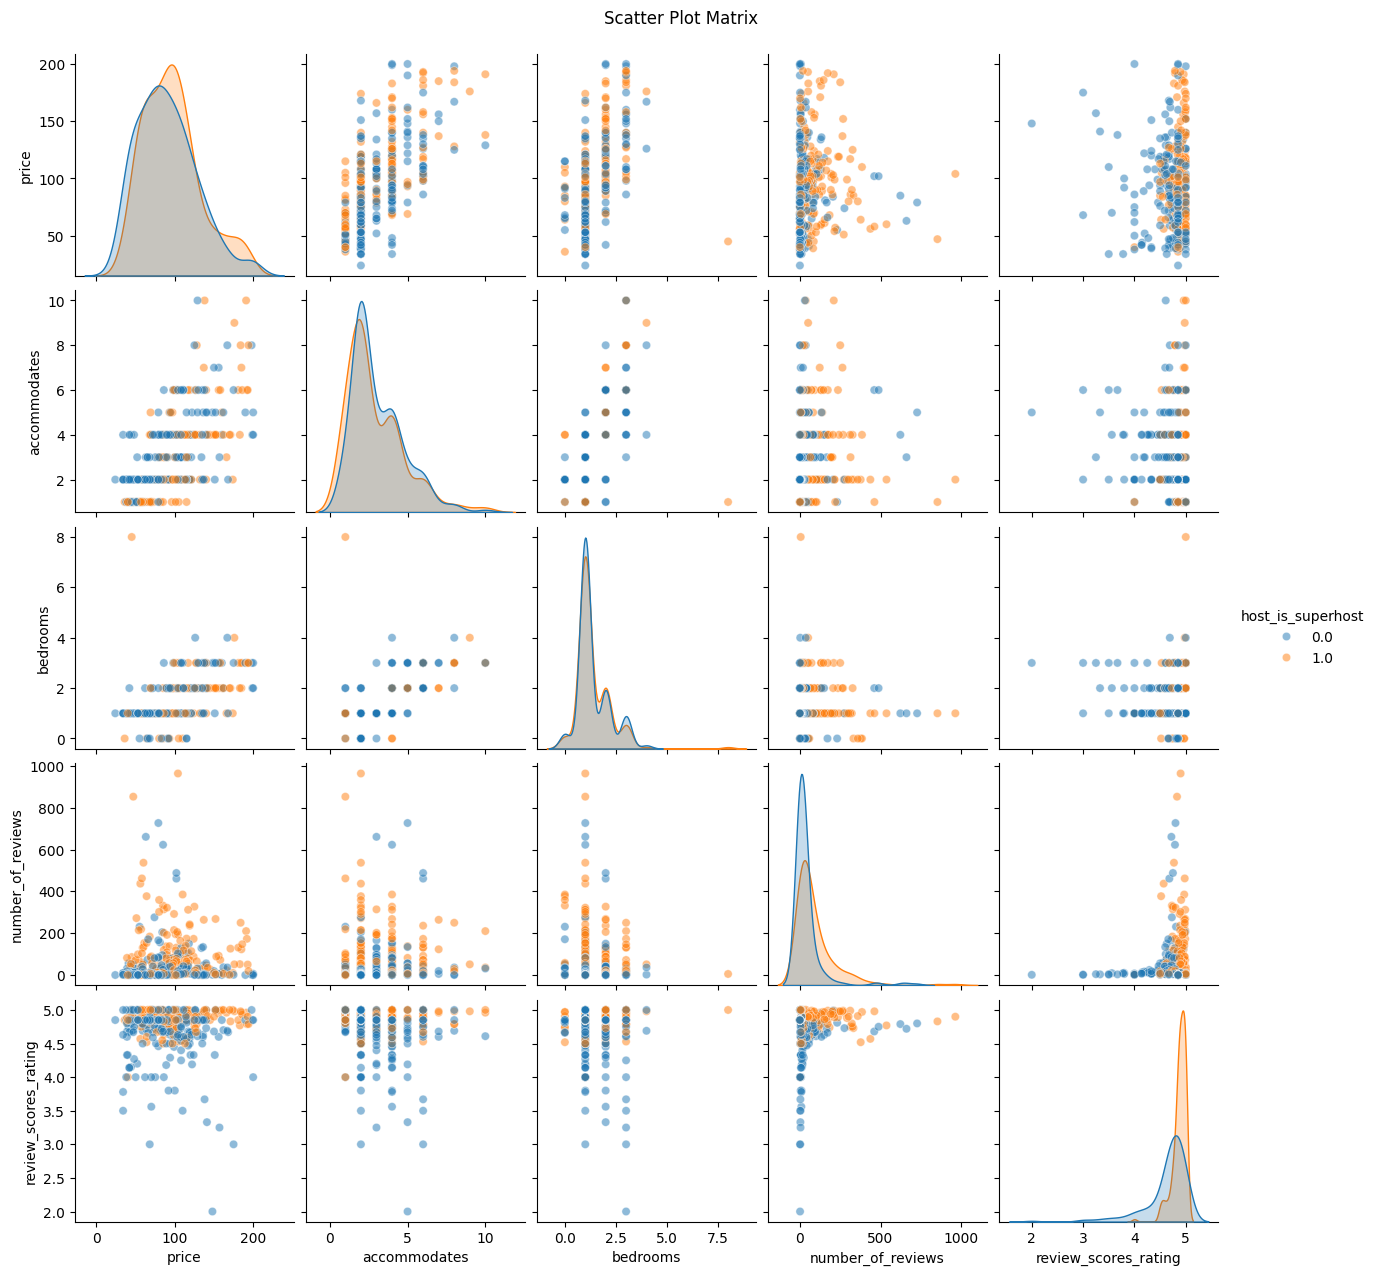

In [28]:
# Pick the most important columns only (keep it simple)
scatter_cols = ['price', 'accommodates', 'bedrooms', 
                'number_of_reviews', 'review_scores_rating', 
                'host_is_superhost']

sns.pairplot(df[scatter_cols], 
             hue='host_is_superhost',   # color by superhost yes/no
             plot_kws={'alpha': 0.5})   # make dots slightly transparent

plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.show()

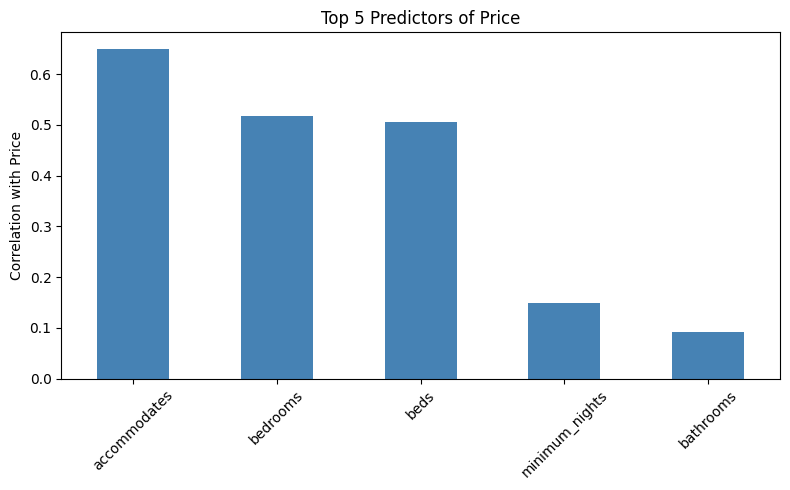

accommodates      0.649978
bedrooms          0.516908
beds              0.505613
minimum_nights    0.148936
bathrooms         0.091195
Name: price, dtype: float64


In [29]:
# Correlation with price only
price_corr = df[corr_cols].corr()['price'].drop('price')

# Sort by absolute value (strongest relationship first)
price_corr = price_corr.abs().sort_values(ascending=False)

# Plot top 5
plt.figure(figsize=(8, 5))
price_corr.head(5).plot(kind='bar', color='steelblue')
plt.title('Top 5 Predictors of Price')
plt.ylabel('Correlation with Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(price_corr.head(5))

In [30]:
from scipy import stats

# Split into 2 groups
superhost_prices = df[df['host_is_superhost'] == 1]['price']
non_superhost_prices = df[df['host_is_superhost'] == 0]['price']

# Run T-Test
t_stat, p_value = stats.ttest_ind(superhost_prices, non_superhost_prices)

print(f"Superhost avg price:     ${superhost_prices.mean():.2f}")
print(f"Non-superhost avg price: ${non_superhost_prices.mean():.2f}")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("\n Result: Significant difference superhosts charges differently")
else:
    print("\n Result: No difference price is similar for both")

Superhost avg price:     $96.48
Non-superhost avg price: $90.05

T-statistic: 1.7201
P-value:     0.0862

 Result: No difference price is similar for both


In [31]:
# Get price for each neighbourhood
groups = [group['price'].values 
          for name, group in df.groupby('neighbourhood_cleansed')]

# Run ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ Result: Price DOES differ across neighbourhoods")
else:
    print("\n❌ Result: Price is similar across all neighbourhoods")

# Show average price per neighbourhood
print("\nAvg price per neighbourhood:")
print(df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).to_string())

F-statistic: 8.3547
P-value:     0.0000

✅ Result: Price DOES differ across neighbourhoods

Avg price per neighbourhood:
neighbourhood_cleansed
FIFTEENTH WARD     140.090909
TWELFTH WARD       137.000000
FIRST WARD         127.750000
EIGHTH WARD        126.000000
SECOND WARD        105.804878
FOURTH WARD        103.733333
SEVENTH WARD       100.833333
SIXTH WARD          99.905263
THIRD WARD          90.258065
THIRTEENTH WARD     88.256410
NINTH WARD          85.750000
TENTH WARD          83.780488
FOURTEENTH WARD     75.772727
FIFTH WARD          66.066667
ELEVENTH WARD       53.592593


In [32]:
# Mann-Whitney U Test: Is superhost price difference real?

from scipy.stats import mannwhitneyu

superhost = df[df['host_is_superhost'] == 1]['price']
non_superhost = df[df['host_is_superhost'] == 0]['price']

stat, p_value = mannwhitneyu(superhost, non_superhost, alternative='two-sided')

print(f"Superhost median price:     ${superhost.median():.2f}")
print(f"Non-Superhost median price: ${non_superhost.median():.2f}")
print(f"\nMann-Whitney U Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Result: Significant price difference between superhosts and non-superhosts")
else:
    print("❌ Result: No significant price difference between superhosts and non-superhosts")

Superhost median price:     $93.50
Non-Superhost median price: $85.00

Mann-Whitney U Statistic: 21483.0000
P-value: 0.0810
❌ Result: No significant price difference between superhosts and non-superhosts


In [33]:
pip show streamlit

Name: streamlit
Version: 1.51.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: Snowflake Inc
Author-email: hello@streamlit.io
License: Apache License 2.0
Location: C:\ProgramData\anaconda3\Lib\site-packages
Requires: altair, blinker, cachetools, click, gitpython, numpy, packaging, pandas, pillow, protobuf, pyarrow, requests, tenacity, toml, tornado, typing-extensions, watchdog
Required-by: 
Note: you may need to restart the kernel to use updated packages.
